# Titanic Survival Prediction 🚢

In this project we analyze the Titanic dataset and build a machine learning model to predict whether a passenger survived or not.

Dataset: Titanic - Machine Learning from Disaster (Kaggle)

## Loading the Dataset

We load the Titanic dataset from the Kaggle competition.  
The training dataset contains information about passengers and whether they survived.

In [35]:
import pandas as pd
import numpy as np

train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Structure

Let's inspect the dataset to understand its structure, column names, and data types.

In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Missing Values

Real-world datasets often contain missing values.  
We check which columns contain missing data.

In [37]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Basic Statistics

We examine summary statistics of numerical columns such as age, fare, and passenger class.

In [38]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Exploratory Data Analysis (EDA)

Before building a machine learning model, it is important to explore the dataset and understand relationships between variables.

We start by analyzing how survival relates to passenger gender.

In [39]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

## Survival Distribution

Let's visualize how many passengers survived and how many did not survive.

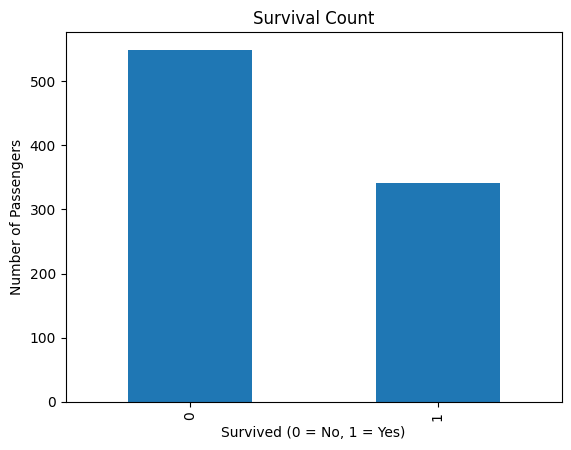

In [40]:
import matplotlib.pyplot as plt

train["Survived"].value_counts().plot(kind="bar")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

## Survival by Gender

Now we analyze whether gender affected survival chances.

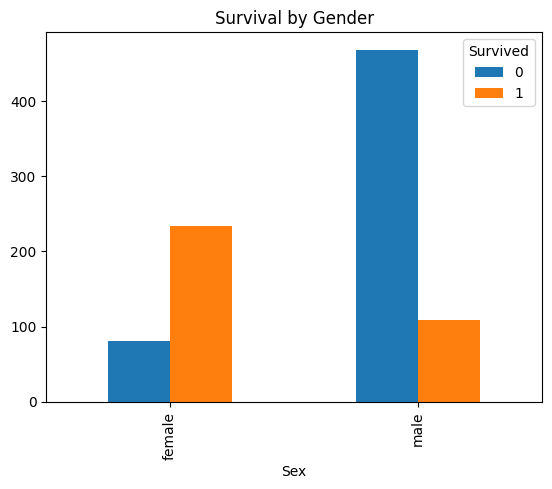

In [41]:
train.groupby(["Sex","Survived"]).size().unstack().plot(kind="bar")

plt.title("Survival by Gender")

plt.show()

### Observation

From the plot we observe that female passengers had a much higher survival rate compared to male passengers.

## Survival by Passenger Class

Passenger class may have influenced survival chances.  
First class passengers likely had better access to lifeboats compared to third class passengers.

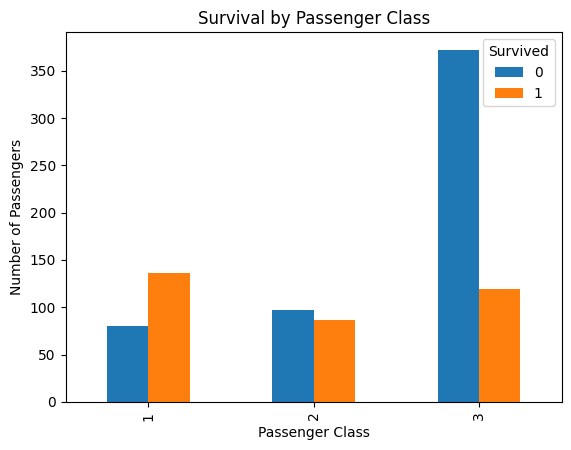

In [42]:
train.groupby(["Pclass","Survived"]).size().unstack().plot(kind="bar")

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")

plt.ylabel("Number of Passengers")

plt.show()

### Observation

From the plot we observe that first class passengers had a higher survival rate compared to third class passengers.

Passengers in lower classes had lower chances of survival.

## Age Distribution

Let's examine the age distribution of passengers in the dataset.

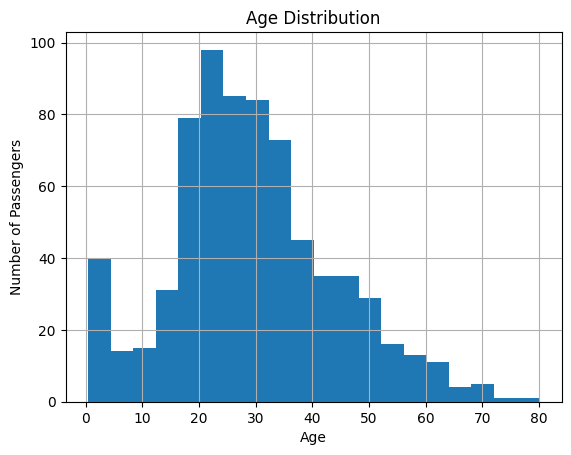

In [43]:
train["Age"].hist(bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Number of Passengers")

plt.show()

## Data Cleaning

Before training a machine learning model, we need to handle missing values.

- Missing values in **Age** are filled using the median.
- Missing values in **Fare** are filled using the median.
- The **Cabin** column contains too many missing values and will be removed.
- Missing values in **Embarked** are filled using the most frequent value (mode).

In [44]:
train["Age"].fillna(train["Age"].median(), inplace=True)
test["Age"].fillna(test["Age"].median(), inplace=True)

test["Fare"].fillna(test["Fare"].median(), inplace=True)

train.drop("Cabin", axis=1, inplace=True, errors="ignore")
test.drop("Cabin", axis=1, inplace=True, errors="ignore")

train["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_55/311839460.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["Age"].fillna(train["Age"].median(), inplace=True)
/tmp/ipykernel_55/311839460.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [45]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Feature Engineering

In [46]:
# Family Size feature
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

# IsAlone feature
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

# Extract Title from Name
train["Title"] = train["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
test["Title"] = test["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Encode titles
title_map = {"Mr":0,"Miss":1,"Mrs":2,"Master":3}

train["Title"] = train["Title"].map(title_map).fillna(4)
test["Title"] = test["Title"].map(title_map).fillna(4)

## Encoding Categorical Variables

Machine learning models require numerical input.  
Therefore we convert categorical variables into numbers.

- Sex: male → 0, female → 1  
- Embarked: S → 0, C → 1, Q → 2

In [47]:
train["Sex"] = train["Sex"].map({"male":0, "female":1})
test["Sex"] = test["Sex"].map({"male":0, "female":1})

train["Embarked"] = train["Embarked"].map({"S":0, "C":1, "Q":2})
test["Embarked"] = test["Embarked"].map({"S":0, "C":1, "Q":2})

## Feature Selection

We select the relevant features that will be used to train the machine learning model.

In [48]:
features = [
"Pclass",
"Sex",
"Age",
"SibSp",
"Parch",
"Fare",
"Embarked",
"FamilySize",
"IsAlone",
"Title"
]

X = train[features]
y = train["Survived"]

X_test = test[features]

## Model Training

We train a Random Forest Classifier to predict passenger survival.

In [49]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    random_state=42
)
model.fit(X, y)

RandomForestClassifier(max_depth=5, n_estimators=500, random_state=42)

## Making Predictions

We use the trained model to predict survival for the test dataset.

In [50]:
predictions = model.predict(X_test)

## Creating Submission File

Finally, we create the submission file required for the Kaggle competition.

In [51]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

submission.to_csv("submission.csv", index=False)